# Modeling

---


## Pendekatan

| Aspek | Keputusan |
|-------|-----------|
| Metrik utama | **F1 Macro** dimana lebih adil untuk multiclass (Low/Medium/High) |
| Evaluasi akhir | Held out test set yang sama untuk semua model |
| Deteksi overfit | Learning curve dengan train vs validation F1 across training sizes |

**Model yang diuji:** Logistic Regression, SVM, Random Forest, Naive Bayes, KNN, ditambah dengan model soft-voting ensemble dengan bobot yang sama untuk masing-masing model sebagai final prediction

## 1. Import Library dan Konfigurasi

Library yang digunakan meliputi:
- **pandas/numpy** untuk manipulasi data.
- **matplotlib/seaborn** untuk visualisasi.
- **scikit-learn** untuk split data, pipeline preprocessing, training model, evaluasi, dan cross-validation.
- **joblib/json** untuk menyimpan model dan metadata deployment.

In [67]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.Set2.colors)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
LABELS = ["Low", "Medium", "High"]
LABEL_TO_INT = {label: idx for idx, label in enumerate(LABELS)}
INT_TO_LABEL = {idx: label for label, idx in LABEL_TO_INT.items()}

FEATURE_COLS = [
    "age", "experience_years", "daily_work_hours", "sleep_hours",
    "caffeine_intake", "bugs_per_day", "commits_per_day",
    "meetings_per_day", "screen_time", "exercise_hours",
]

TARGET_COL = "burnout_level"
DROPPED_COLS = ["stress_level"]
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

## 2. Load Raw Dataset

Model dilatih dari data mentah (`dataset.csv`) agar preprocessing dilakukan hanya berdasarkan data training di dalam pipeline. Ini lebih aman dibanding melakukan imputasi sebelum train-test split karena bisa menyebabkan informasi dari test set ikut masuk ke proses training.

In [68]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
print(f'Fitur: {[c for c in df.columns if c != "burnout_encoded"]}')
display(df.head())
display(df.isna().sum().to_frame("missing_count"))
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))

Shape: (7000, 12)
Fitur: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


,missing_count
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


,count
burnout_level,
Medium,3485
High,1782
Low,1593
NaN,140


## 3. Target Handling dan Feature Selection

Baris dengan target kosong dihapus karena target adalah ground truth. Sedangkan, fitur numerik yang kosong tidak dihapus di sini karena akan ditangani oleh `SimpleImputer` dengan teknik median di dalam pipeline.

`stress_level` tidak digunakan sebagai fitur final karena terlalu dekat secara konsep dengan label burnout. Jika fitur ini digunakan, model bisa terlihat bagus tetapi sebenarnya sudah "mempelajari" output secara tidak langsung

In [69]:
df_model = df.dropna(subset=[TARGET_COL]).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].map(LABEL_TO_INT)

print("Original rows:", len(df))
print("Rows used after dropping missing targets:", len(df_model))
print("Dropped missing target rows:", df[TARGET_COL].isna().sum())
print("Features used:", FEATURE_COLS)
print("Dropped columns:", DROPPED_COLS)

display(X.head())

Original rows: 7000
Rows used after dropping missing targets: 6860
Dropped missing target rows: 140
Features used: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours']
Dropped columns: ['stress_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36


## 4. Stratified Train-Test Split

Data dibagi menjadi 80% training dan 20% testing. Parameter `stratify=y` digunakan agar proporsi kelas Low, Medium, dan High tetap seimbang pada train set dan test set.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True).sort_index().rename(index=INT_TO_LABEL))
print("Test class distribution:")
print(y_test.value_counts(normalize=True).sort_index().rename(index=INT_TO_LABEL))

Train shape: (5488, 10)
Test shape: (1372, 10)
Train class distribution:
burnout_level
Low       0.232143
Medium    0.508017
High      0.259840
Name: proportion, dtype: float64
Test class distribution:
burnout_level
Low       0.232507
Medium    0.508017
High      0.259475
Name: proportion, dtype: float64


### Visualisasi Distribusi Kelas Setelah Split

Visualisasi ini memastikan bahwa pembagian train-test tidak merusak proporsi kelas target. Ini penting karena evaluasi bisa bias jika salah satu kelas terlalu banyak/hilang pada test set.

,train,test
burnout_level,,
Low,0.232143,0.232507
Medium,0.508017,0.508017
High,0.259840,0.259475


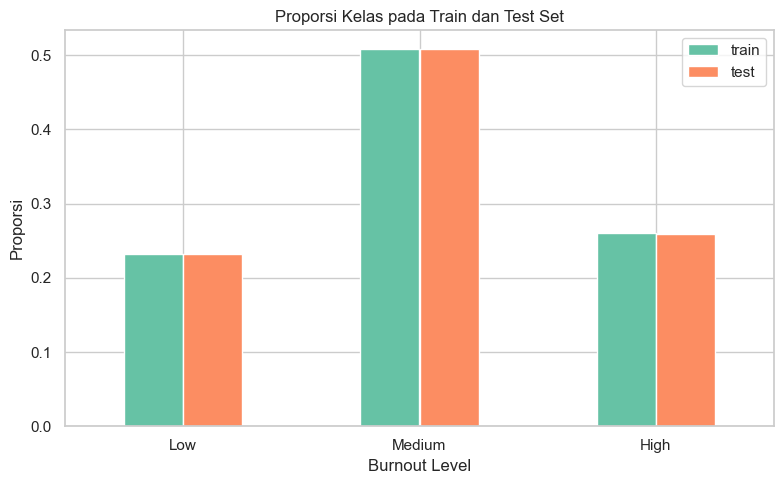

In [71]:
split_dist = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
})
split_dist.index = split_dist.index.map(INT_TO_LABEL)

display(split_dist)

split_dist.plot(kind="bar", figsize=(8, 5))
plt.title("Proporsi Kelas pada Train dan Test Set")
plt.xlabel("Burnout Level")
plt.ylabel("Proporsi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Classical ML Pipelines

Setiap model dibuat dalam bentuk pipeline agar preprocessing masuk ke proses cross-validation dengan benar.

Model yang digunakan:
- **Logistic Regression**: baseline linear yang mudah dijelaskan.
- **SVM**: model margin-based dengan kernel RBF untuk pola non-linear.
- **Random Forest**: ensemble decision tree yang relatif kuat dan bisa memberi feature importance.
- **Naive Bayes**: baseline probabilistik sederhana.
- **KNN**: model berbasis jarak yang sensitif terhadap scaling.

Scaling diberikan pada model yang sensitif terhadap skala fitur, seperti Logistic Regression, SVM, dan KNN.

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1,
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="lbfgs"
        )),
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        )),
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_split=15,
            min_samples_leaf=6,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        )),
    ]),

    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GaussianNB(
            var_smoothing=1e-9
        )),
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=11,
            weights="uniform",
            metric="manhattan"
        )),
    ]),
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## 6. Helper Functions untuk Evaluasi dan Visualisasi

Fungsi ini dibuat agar proses evaluasi setiap model konsisten. Metrik utama adalah **F1 Macro** karena setiap kelas burnout perlu dianggap sama pentingnya, bukan hanya kelas dengan jumlah mayoritas.

In [73]:
results = {}


def evaluate_model(name, estimator, X_train, X_test, y_train, y_test):
    print(f"Training {name}...")
    cv_scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)

    fitted_estimator = clone(estimator)
    fitted_estimator.fit(X_train, y_train)
    y_pred = fitted_estimator.predict(X_test)

    results[name] = {
        "estimator": fitted_estimator,
        "cv_f1_macro": float(cv_scores.mean()),
        "cv_f1_macro_std": float(cv_scores.std()),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "classification_report": classification_report(y_test, y_pred, target_names=LABELS, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }

    print(f"CV F1 Macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test F1 Macro: {results[name]['test_f1_macro']:.4f}")
    print(f"Test Accuracy : {results[name]['test_accuracy']:.4f}")
    print(classification_report(y_test, y_pred, target_names=LABELS))

    return fitted_estimator


def plot_confusion_matrix_for_model(name):
    cm = np.array(results[name]["confusion_matrix"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_learning_curve_for_model(name, estimator):
    # Learning curve memakai subset agar notebook tetap ringan saat dijalankan di laptop
    # Evaluasi utama tetap memakai seluruh X_train pada cell training model
    if len(X_train) > 1500:
        X_lc, _, y_lc, _ = train_test_split(
            X_train,
            y_train,
            train_size=1500,
            random_state=RANDOM_STATE,
            stratify=y_train
        )
    else:
        X_lc, y_lc = X_train, y_train

    lc_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_sizes, train_scores, val_scores = learning_curve(
        clone(estimator),
        X_lc,
        y_lc,
        cv=lc_cv,
        scoring="f1_macro",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    gap = train_mean[-1] - val_mean[-1]

    if gap > 0.10:
        diagnosis = f"Overfit gap = {gap:.3f} (> 0.10)"
    elif val_mean[-1] < 0.50:
        diagnosis = f"Underfit val F1 = {val_mean[-1]:.3f} (< 0.50)"
    else:
        diagnosis = f"Good fit gap = {gap:.3f}"

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        train_sizes,
        train_mean,
        "o-",
        color="#2ecc71",
        linewidth=2,
        label="Train F1 Macro"
    )

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#2ecc71"
    )

    ax.plot(
        train_sizes,
        val_mean,
        "o-",
        color="#e74c3c",
        linewidth=2,
        label="Validation F1 Macro"
    )

    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#e74c3c"
    )

    ax.set_title(
        f"Learning Curve - {name}\n{diagnosis}",
        fontweight="bold",
        fontsize=11
    )

    ax.set_xlabel("Training Size")
    ax.set_ylabel("F1 Macro")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## 7. Train dan Evaluate Semua Model

Semua model dilatih dan dievaluasi dengan prosedur yang sama. Tujuannya agar perbandingan antar model adil dan mudah dijelaskan.

Training Logistic Regression...
CV F1 Macro : 0.7699 ± 0.0099
Test F1 Macro: 0.7781
Test Accuracy : 0.7748
              precision    recall  f1-score   support

         Low       0.71      0.84      0.77       319
      Medium       0.83      0.70      0.76       697
        High       0.76      0.85      0.80       356

    accuracy                           0.77      1372
   macro avg       0.77      0.80      0.78      1372
weighted avg       0.78      0.77      0.77      1372



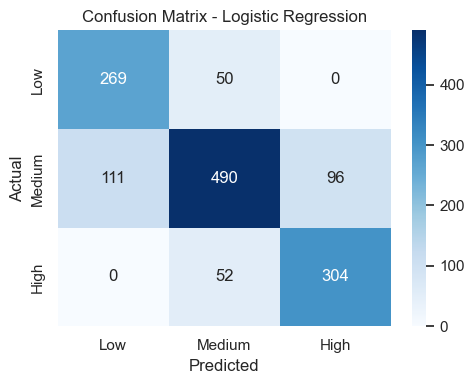

Training SVM...
CV F1 Macro : 0.7610 ± 0.0123
Test F1 Macro: 0.7625
Test Accuracy : 0.7587
              precision    recall  f1-score   support

         Low       0.69      0.84      0.76       319
      Medium       0.81      0.68      0.74       697
        High       0.75      0.83      0.79       356

    accuracy                           0.76      1372
   macro avg       0.75      0.79      0.76      1372
weighted avg       0.77      0.76      0.76      1372



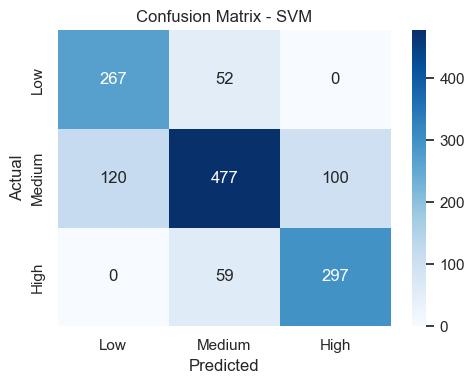

Training Random Forest...
CV F1 Macro : 0.7268 ± 0.0142
Test F1 Macro: 0.7455
Test Accuracy : 0.7405
              precision    recall  f1-score   support

         Low       0.67      0.83      0.75       319
      Medium       0.80      0.65      0.72       697
        High       0.72      0.84      0.77       356

    accuracy                           0.74      1372
   macro avg       0.73      0.77      0.75      1372
weighted avg       0.75      0.74      0.74      1372



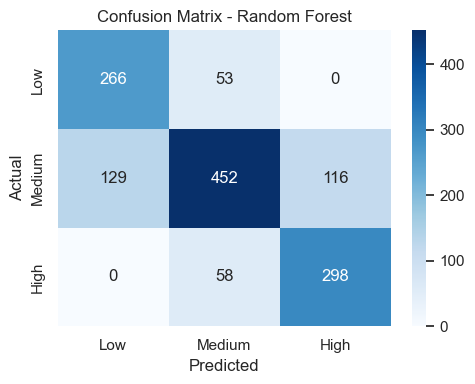

Training Naive Bayes...
CV F1 Macro : 0.7291 ± 0.0118
Test F1 Macro: 0.7649
Test Accuracy : 0.7697
              precision    recall  f1-score   support

         Low       0.77      0.72      0.74       319
      Medium       0.76      0.80      0.78       697
        High       0.80      0.75      0.77       356

    accuracy                           0.77      1372
   macro avg       0.77      0.76      0.76      1372
weighted avg       0.77      0.77      0.77      1372



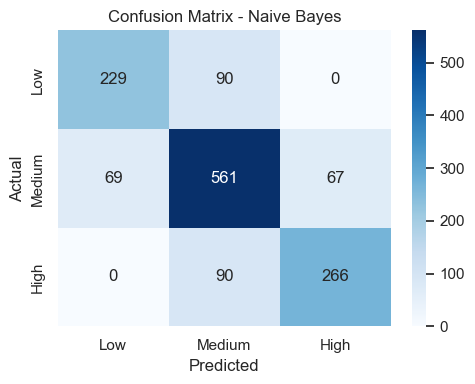

Training KNN...
CV F1 Macro : 0.7206 ± 0.0171
Test F1 Macro: 0.7453
Test Accuracy : 0.7580
              precision    recall  f1-score   support

         Low       0.78      0.64      0.70       319
      Medium       0.72      0.85      0.78       697
        High       0.84      0.68      0.75       356

    accuracy                           0.76      1372
   macro avg       0.78      0.72      0.75      1372
weighted avg       0.77      0.76      0.76      1372



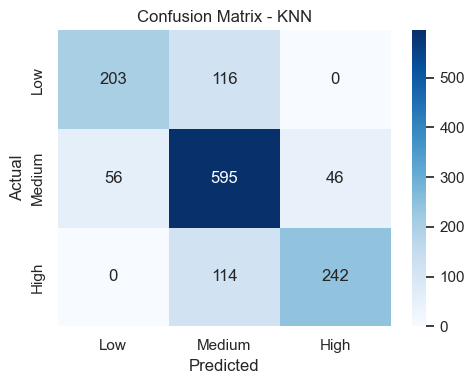

In [74]:
for name, pipe in models.items():
    evaluate_model(name, pipe, X_train, X_test, y_train, y_test)
    plot_confusion_matrix_for_model(name)

## 8. Learning Curve

Learning curve digunakan untuk melihat apakah model cenderung overfitting atau underfitting:
- Jika skor train tinggi tetapi validasi rendah, ada indikasi overfitting.
- Jika train dan validasi sama-sama rendah, ada indikasi underfitting.
- Jika validasi naik saat data bertambah, model masih mungkin terbantu oleh data tambahan.

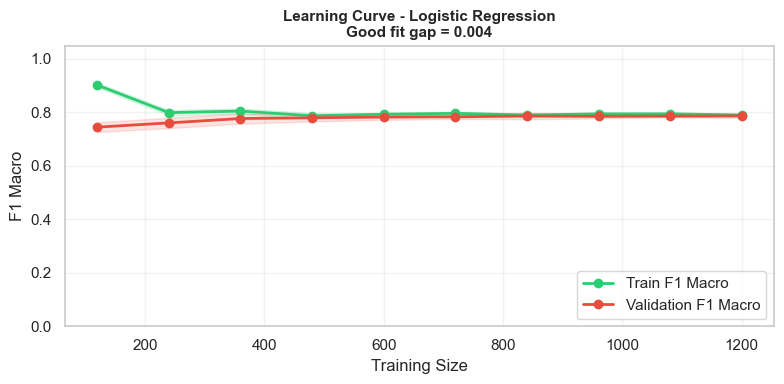

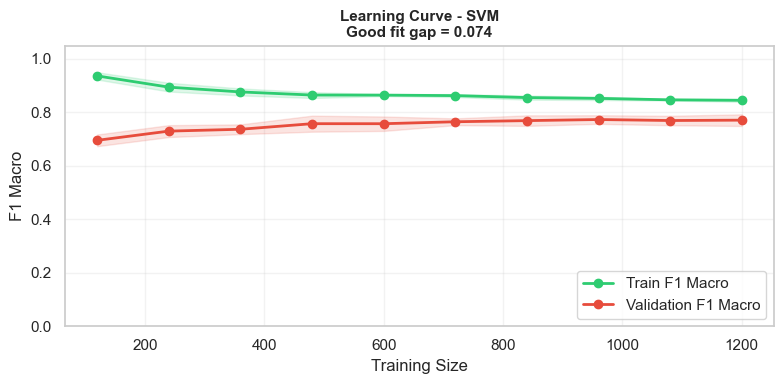

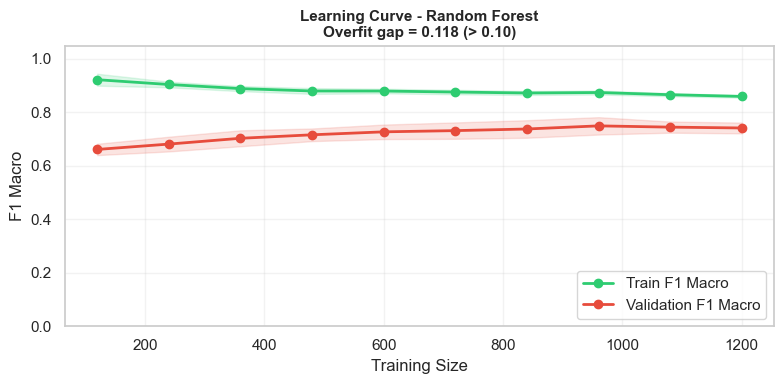

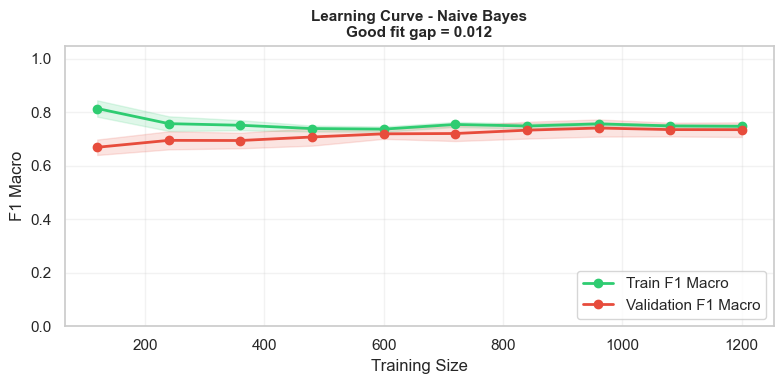

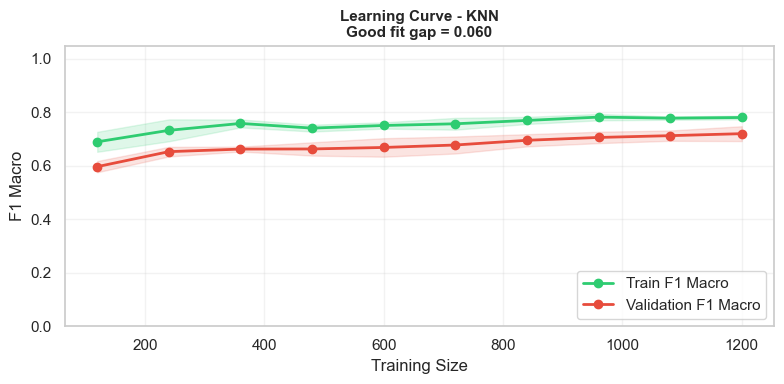

In [75]:
for name, pipe in models.items():
    plot_learning_curve_for_model(name, pipe)

## 9. Perbandingan Model

Tabel dan grafik berikut membandingkan performa semua model berdasarkan CV F1 Macro, Test F1 Macro, dan Test Accuracy. Model terbaik dipilih berdasarkan Test F1 Macro karena metrik ini lebih adil untuk klasifikasi multi-kelas.

,model,cv_f1_macro,cv_f1_macro_std,test_f1_macro,test_accuracy
0,Logistic Regression,0.769902,0.009856,0.778061,0.774781
3,Naive Bayes,0.729064,0.011799,0.764895,0.769679
1,SVM,0.761039,0.012283,0.762544,0.758746
2,Random Forest,0.726832,0.014184,0.745528,0.740525
4,KNN,0.720566,0.017126,0.745280,0.758017


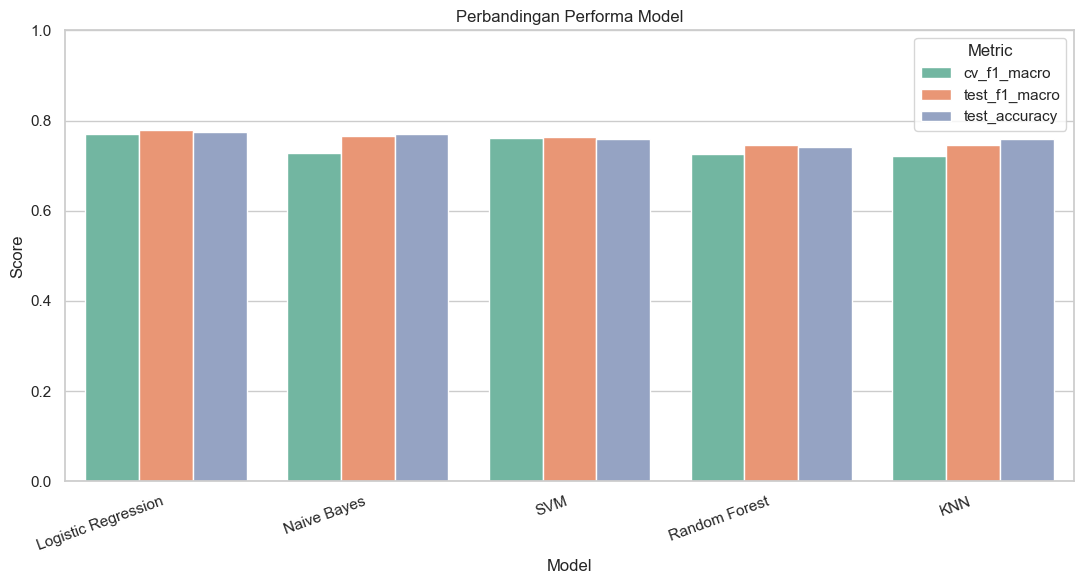

In [76]:
summary_df = pd.DataFrame([
    {
        "model": name,
        "cv_f1_macro": info["cv_f1_macro"],
        "cv_f1_macro_std": info["cv_f1_macro_std"],
        "test_f1_macro": info["test_f1_macro"],
        "test_accuracy": info["test_accuracy"],
    }
    for name, info in results.items()
]).sort_values("test_f1_macro", ascending=False)

display(summary_df)

plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["cv_f1_macro", "test_f1_macro", "test_accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="Set2")
plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 10. Evaluate Soft-Voting Ensemble

Soft-voting ensemble menggabungkan probabilitas prediksi dari beberapa model. Ensemble hanya dipakai karena dievaluasi secara eksplisit. Jika performanya tidak lebih baik dari model tunggal, model tunggal tetap bisa menjadi pilihan final.

,model,cv_f1_macro,cv_f1_macro_std,test_f1_macro,test_accuracy
5,Soft Voting Ensemble,NaN,NaN,0.793597,0.796647
0,Logistic Regression,0.769902,0.009856,0.778061,0.774781
1,Naive Bayes,0.729064,0.011799,0.764895,0.769679
2,SVM,0.761039,0.012283,0.762544,0.758746
3,Random Forest,0.726832,0.014184,0.745528,0.740525
4,KNN,0.720566,0.017126,0.745280,0.758017


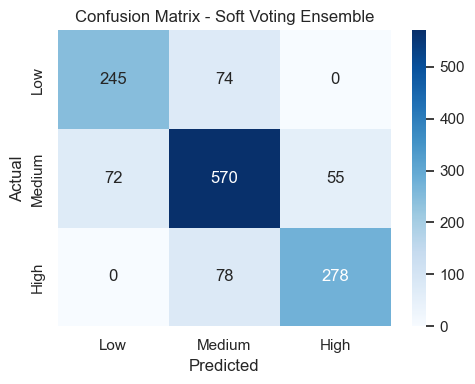

              precision    recall  f1-score   support

         Low       0.77      0.77      0.77       319
      Medium       0.79      0.82      0.80       697
        High       0.83      0.78      0.81       356

    accuracy                           0.80      1372
   macro avg       0.80      0.79      0.79      1372
weighted avg       0.80      0.80      0.80      1372



In [77]:
FILENAME_MAP = {
    "Logistic Regression": "logistic_regression",
    "SVM": "svm",
    "Random Forest": "random_forest",
    "Naive Bayes": "naive_bayes",
    "KNN": "knn",
}

ensemble = VotingClassifier(
    estimators=[(FILENAME_MAP[name], results[name]["estimator"]) for name in models],
    voting="soft",
    n_jobs=1,
)
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

results["Soft Voting Ensemble"] = {
    "estimator": ensemble,
    "cv_f1_macro": None,
    "cv_f1_macro_std": None,
    "test_accuracy": float(accuracy_score(y_test, y_pred_ensemble)),
    "test_f1_macro": float(f1_score(y_test, y_pred_ensemble, average="macro")),
    "classification_report": classification_report(y_test, y_pred_ensemble, target_names=LABELS, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, y_pred_ensemble).tolist(),
}

summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "model": "Soft Voting Ensemble",
        "cv_f1_macro": np.nan,
        "cv_f1_macro_std": np.nan,
        "test_f1_macro": results["Soft Voting Ensemble"]["test_f1_macro"],
        "test_accuracy": results["Soft Voting Ensemble"]["test_accuracy"],
    }])
], ignore_index=True).sort_values("test_f1_macro", ascending=False)

display(summary_df)
plot_confusion_matrix_for_model("Soft Voting Ensemble")
print(classification_report(y_test, y_pred_ensemble, target_names=LABELS))

## 11. Final Model Selection

Model final dipilih berdasarkan nilai **Test F1 Macro** tertinggi. Setelah model final dipilih, confusion matrix dan classification report ditampilkan lagi agar hasil akhir mudah dibaca.

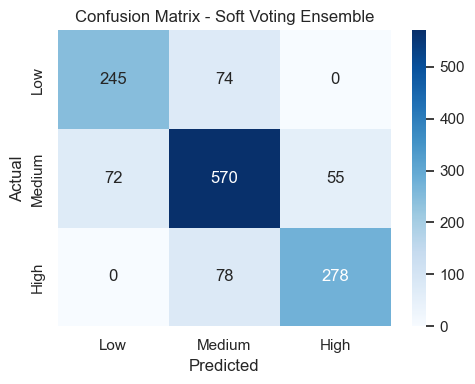

Final selected model: Soft Voting Ensemble
              precision    recall  f1-score   support

         Low       0.77      0.77      0.77       319
      Medium       0.79      0.82      0.80       697
        High       0.83      0.78      0.81       356

    accuracy                           0.80      1372
   macro avg       0.80      0.79      0.79      1372
weighted avg       0.80      0.80      0.80      1372



In [78]:
final_model_name = summary_df.iloc[0]["model"]
final_estimator = results[final_model_name]["estimator"]
y_pred_final = final_estimator.predict(X_test)
final_cm = np.array(results[final_model_name]["confusion_matrix"])

plt.figure(figsize=(5, 4))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Final selected model:", final_model_name)
print(classification_report(y_test, y_pred_final, target_names=LABELS))

## 12. Feature Importance & Seleksi Fitur untuk Deployment

Random Forest secara native menghasilkan **feature importance** — seberapa besar kontribusi tiap fitur dalam mengurangi impurity (Gini) di semua tree. Ini bisa dipakai sebagai panduan untuk memilih fitur mana yang wajib diisi user saat deployment.

Setelah melihat ranking, kita uji apakah model dengan hanya **top-N fitur** masih punya performa yang sebanding — kalau drop F1 Macro-nya kecil (< 2%), trade-off UX vs performa worth it.

,feature,importance
2,daily_work_hours,0.287040
5,bugs_per_day,0.278345
8,screen_time,0.170881
7,meetings_per_day,0.126238
3,sleep_hours,0.066010
4,caffeine_intake,0.034176
9,exercise_hours,0.020586
6,commits_per_day,0.005889
0,age,0.005494
1,experience_years,0.005340


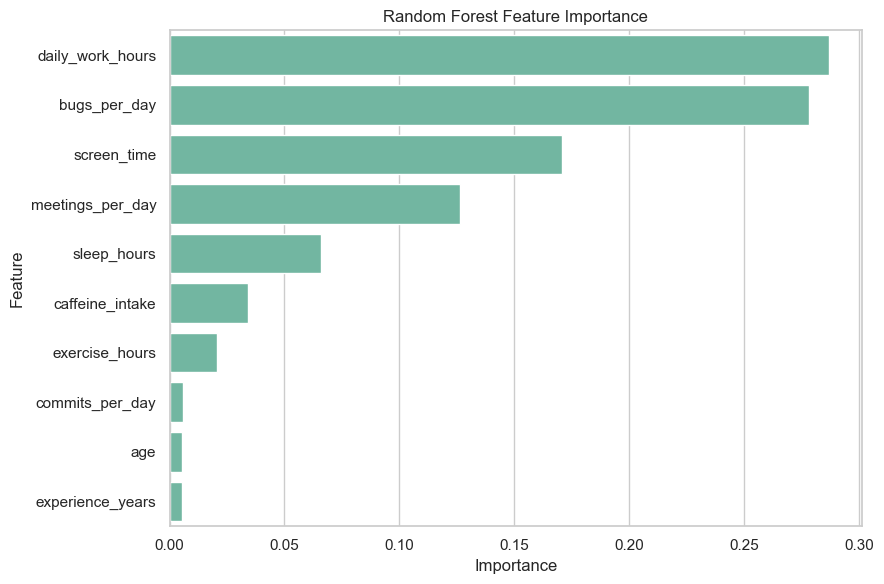

In [79]:
rf_pipeline = results["Random Forest"]["estimator"]
rf_model = rf_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance, x="importance", y="feature", color="C0")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Insight Feature Importance

Feature importance digunakan sebagai bahan interpretasi agar model tidak terlihat seperti black box sepenuhnya. Namun, perlu diingat bahwa importance dari Random Forest tidak selalu berarti hubungan sebab-akibat. Nilai ini hanya menunjukkan seberapa sering dan seberapa kuat fitur membantu pembagian node pada Random Forest.

## 13. Save Models and Metadata

Backend membutuhkan file model, daftar urutan fitur, dan metadata. Urutan fitur disimpan agar input dari aplikasi selalu sesuai dengan urutan fitur saat training.

In [80]:
for name in models:
    joblib.dump(results[name]["estimator"], MODEL_DIR / f"{FILENAME_MAP[name]}.pkl")

joblib.dump(results["Soft Voting Ensemble"]["estimator"], MODEL_DIR / "soft_voting_ensemble.pkl")
joblib.dump(results[final_model_name]["estimator"], MODEL_DIR / "final_model.pkl")

metadata = {
    "labels": LABELS,
    "feature_columns": FEATURE_COLS,
    "dropped_columns": DROPPED_COLS,
    "target_column": TARGET_COL,
    "target_mapping": LABEL_TO_INT,
    "rows_original": int(len(df)),
    "rows_used_after_dropping_missing_target": int(len(df_model)),
    "missing_target_rows_dropped": int(df[TARGET_COL].isna().sum()),
    "split": {"test_size": 0.2, "random_state": RANDOM_STATE, "stratified": True},
    "cv": {"type": "StratifiedKFold", "n_splits": 5, "shuffle": True, "random_state": RANDOM_STATE},
    "final_model": final_model_name,
    "results": {k: {kk: vv for kk, vv in v.items() if kk != "estimator"} for k, v in results.items()},
}

with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved models and metadata to:", MODEL_DIR.resolve())

Saved models and metadata to: /Users/dzakyrizha/1. VSCODE/ProjectML/burnout-prediction-fixed/models


## 14. Notes

| Aspek | Details |
|---|---|
| Data source | Model dilatih dari raw `dataset.csv` agar preprocessing tidak bocor dari test set |
| Missing target | Dihapus karena target sebaiknya bukan data sintetis (hasil impute) |
| Missing fitur | Diimputasi median di dalam pipeline |
| Scaling | Dipakai untuk model yang sensitif skala seperti Logistic Regression, SVM, dan KNN |
| Metrik utama | F1 Macro karena kelas burnout (yang sedikit imbalance) harus dianggap sama penting |
| `stress_level` | Dihapus untuk mengurangi leakage karena terlalu dekat dengan label burnout |
| Model final | Dipilih berdasarkan Test F1 Macro tertinggi |
| Deployment | Model, metadata, dan feature order disimpan di folder `models/` |

In [81]:
import time
import numpy as np
import pandas as pd

def benchmark_latency(model, X_sample, n_runs=500):
    # warm-up
    for _ in range(20):
        model.predict(X_sample)

    latencies = []

    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(X_sample)
        end = time.perf_counter()

        latencies.append((end - start) * 1000)

    return {
        "mean_ms": np.mean(latencies),
        "p50_ms": np.percentile(latencies, 50),
        "p95_ms": np.percentile(latencies, 95),
        "p99_ms": np.percentile(latencies, 99),
        "max_ms": np.max(latencies),
    }


latency_results = []

single_row = X_test.iloc[[0]]

for name, result in results.items():
    model = result["estimator"]
    stats = benchmark_latency(model, single_row)

    latency_results.append({
        "model": name,
        "test_f1_macro": result["test_f1_macro"],
        **stats
    })

latency_df = pd.DataFrame(latency_results).sort_values("p95_ms")
display(latency_df)

,model,test_f1_macro,mean_ms,p50_ms,p95_ms,p99_ms,max_ms
0,Logistic Regression,0.778061,0.353731,0.349750,0.376201,0.440231,0.756833
3,Naive Bayes,0.764895,0.344931,0.324563,0.451978,0.566317,1.074291
1,SVM,0.762544,0.450777,0.446042,0.473339,0.526780,0.765125
4,KNN,0.745280,0.681250,0.639813,0.891238,1.029418,1.402500
2,Random Forest,0.745528,7.113121,6.893042,7.839519,9.369919,16.670958
5,Soft Voting Ensemble,0.793597,9.476903,9.463104,10.494040,12.985659,22.390500
